In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('../dataset/ghi_temp.csv')

In [16]:
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2019,1,1,0,0,0,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,0,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,0,16.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,0,15.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
ghi_col = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI']
df = df[ghi_col]
df.head()

,Year,Month,Day,Hour,Minute,GHI
0,2019,1,1,0,0,0
1,2019,1,1,1,0,0
2,2019,1,1,2,0,0
3,2019,1,1,3,0,0
4,2019,1,1,4,0,0


In [18]:
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [19]:
df.head()

,Year,Month,Day,Hour,Minute,GHI,datetime
0,2019,1,1,0,0,0,2019-01-01 00:00:00
1,2019,1,1,1,0,0,2019-01-01 01:00:00
2,2019,1,1,2,0,0,2019-01-01 02:00:00
3,2019,1,1,3,0,0,2019-01-01 03:00:00
4,2019,1,1,4,0,0,2019-01-01 04:00:00


In [20]:
df = df[['datetime', 'GHI']]

df.set_index('datetime', inplace=True)

df.head()

,GHI
datetime,
2019-01-01 00:00:00,0
2019-01-01 01:00:00,0
2019-01-01 02:00:00,0
2019-01-01 03:00:00,0
2019-01-01 04:00:00,0


In [21]:
print(df.shape)

(8760, 1)


In [22]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

mmscaler = MinMaxScaler(feature_range=(0,1))
mmscaler.fit(df.GHI.values.reshape(-1,1))
scaled_data = mmscaler.transform(df.values)

In [23]:
print(scaled_data)

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


In [24]:
# split point agar train data hanya hingga 30 september pukul 23.00

split_point = len(df[:'2019-9-30 23:00:00'])
print(split_point)

6552


In [25]:
win_size = 24

train_data = scaled_data[:split_point, :]
x_train = []
y_train = []


In [26]:
print(train_data)

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


In [27]:
for i in range(win_size, len(train_data)):
    x_train.append(train_data[i - win_size:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train).reshape(-1, win_size, 1), np.array(y_train)

In [28]:
print(x_train.shape)

(6528, 24, 1)


In [29]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences= False))
model.add(Dense(24))


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,528 (459.09 KB)

 Trainable params: 117,528 (459.09 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

#train the model
history = model.fit(x_train, y_train, batch_size=1, epochs=100)  

Epoch 1/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0237
Epoch 2/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0109
Epoch 3/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.0098
Epoch 4/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0100
Epoch 5/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0091
Epoch 6/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.0090
Epoch 7/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.0096
Epoch 8/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.0096
Epoch 9/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.0095
Epoch 10/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0088
Epoch 11/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0093
Epoch 12/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0083
Epoch 13/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0088
Epoch 14/100
6528/6528 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.0080
E

In [32]:
test_data = scaled_data[len(train_data) - win_size:, :]
x_test = []
y_test = test_data
 
print(test_data.shape)

(2232, 1)


In [33]:
for i in range(win_size, len(test_data)):
    x_test.append(test_data[i - win_size:i, 0])
    

x_test = np.array(x_test)

print(x_test)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [34]:
predictions = model.predict(x_test)
predictions = mmscaler.inverse_transform(predictions)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_7970/156769296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:, -1]


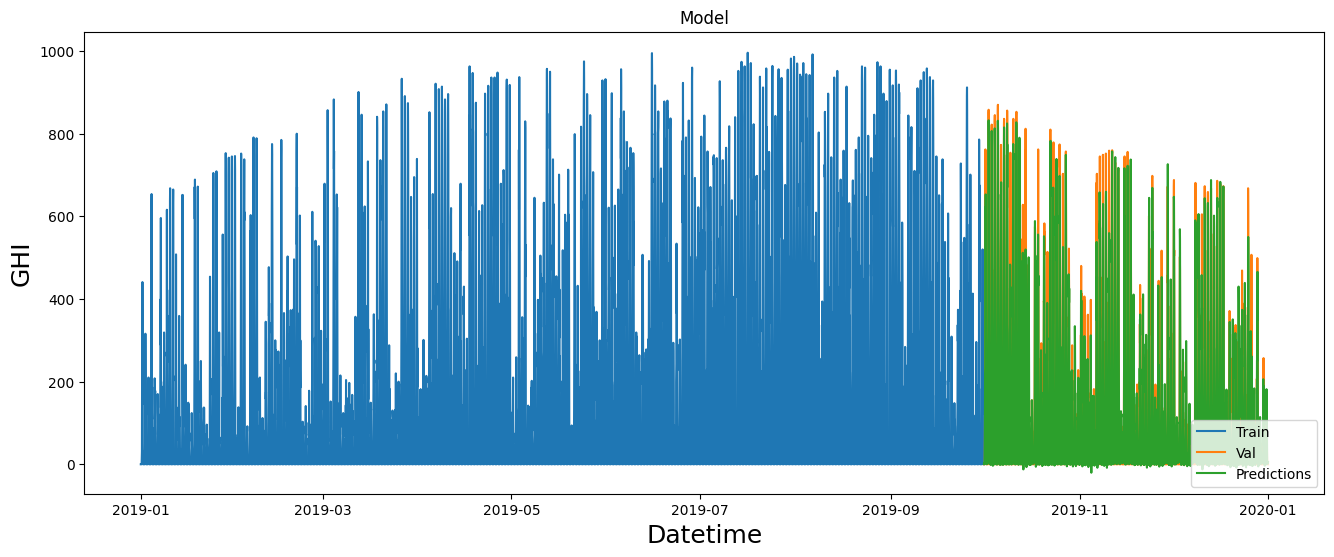

In [35]:
# Plot the data
train = df[:split_point]
valid = df[split_point:]
valid['Predictions'] = predictions[:, -1]

# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Datetime', fontsize=18)
plt.ylabel('GHI', fontsize=18)
plt.plot(train['GHI'])
plt.plot(valid[['GHI', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [36]:
with open('predictions.txt', 'w') as f:
    for prediction in predictions:
        f.write(f"{prediction}\n")

print("Prediksi telah disimpan ke file 'predictions.txt'.")

Prediksi telah disimpan ke file 'predictions.txt'.
